<a href="https://colab.research.google.com/github/lmfandre/Desafio_Clustering/blob/main/Minicurso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Primeiras Funções**
---



In [ ]:
print("Olá!")

Olá!


In [ ]:
# O P maiúsculo leva ao erro!

Print("Olá!")

NameError: name 'Print' is not defined

In [ ]:
# O valor "André" é armazenado na variável "nome"

nome = "André"
print("Bem vindo,", nome)

Bem vindo, André


In [ ]:
# O valor de "nome" depende da entrada (input) do usuário

nome = input("Qual é o seu nome? ")
print("Bem vindo,", nome)

Qual é o seu nome? Mestre dos Magos
Bem vindo, Mestre dos Magos




---


**Dicionários**
---


---





In [ ]:
# Um dicionário é iniciado por chaves {} e permite armazenar várias informações de uma vez

eu = {
    "Nome": "André",
    "Idade": 26
}

In [ ]:
print(eu)

{'Nome': 'André', 'Idade': 26}


In [ ]:
# {} representam um dicionário, [] representam uma lista (que pode estar dentro do dicionário!)

minhas_notas = {
    "Materia":["Matematica", "Geografia", "Portugues", "Quimica"],
    "Nota": [8.5, 6.0, 7.2, 9.0],
    "Horas_estudo": [5, 2, 4, 6]
}

In [ ]:
print(minhas_notas)

{'Materia': ['Matematica', 'Geografia', 'Portugues', 'Quimica'], 'Nota': [8.5, 6.0, 7.2, 9.0], 'Horas_estudo': [5, 2, 4, 6]}




---


**Bibliotecas**
---


---



In [ ]:
# Importe a biblioteca pandas e dê a ela o apelido "pd"

import pandas as pd

In [ ]:
# A variável "df_notas" recebe o DataFrame com os dados de minhas_notas

df_notas = pd.DataFrame(minhas_notas)

In [ ]:
df_notas

,Materia,Nota,Horas_estudo
0,Matematica,8.5,5
1,Geografia,6.0,2
2,Portugues,7.2,4
3,Quimica,9.0,6




---
**Primeiras Análises**
---


---



In [ ]:
# A variável "media" recebe a média (mean) da coluna "Nota" do df_notas

media = df_notas["Nota"].mean()

In [ ]:
print("Média das notas:", media)

Média das notas: 7.675


In [ ]:
nota_maxima = df_notas["Nota"].max()
print("Maior nota:", nota_maxima)

Maior nota: 9.0


In [ ]:
nota_minima = df_notas["Nota"].min()
print("Menor nota:", nota_minima)

Menor nota: 6.0




---

**Dataset Titanic**
---


---




In [ ]:


df = pd.read_csv('/content/train.csv')
df['Family_Size'] = df['SibSp'] + df['Parch']
df = df.drop(columns = {'SibSp', 'Parch'}, axis = 1)
df = df.rename(columns = {
    "PassengerId": "Id_Passageiro",
    "Survived": "Sobreviveu",
    "Pclass": "Classe",
    "Name": "Nome",
    "Sex": "Sexo",
    "Age": "Idade",
    "Ticket": "Bilhete",
    "Fare": "Tarifa",
    "Cabin": "Cabine",
    "Embarked": "Porto_Embarque",
    "Family_Size": "Tamanho_Familia"
})
df.head()

,Id_Passageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Bilhete,Tarifa,Cabine,Porto_Embarque,Tamanho_Familia
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,0


In [ ]:
df.describe()

,Id_Passageiro,Sobreviveu,Classe,Idade,Tarifa,Tamanho_Familia
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,32.204208,0.904602
std,257.353842,0.486592,0.836071,14.526497,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,28.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,38.000000,31.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,512.329200,10.000000


In [ ]:
# Qual foi a taxa de sobrevivência dos passageiros do Titanic?

print(f"Taxa de sobrevivência: {df['Sobreviveu'].mean()*100:.2f}%")

Taxa de sobrevivência: 38.38%


In [ ]:
# Qual a quantidade de pessoas que sobreviveram?

df['Sobreviveu'].value_counts()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

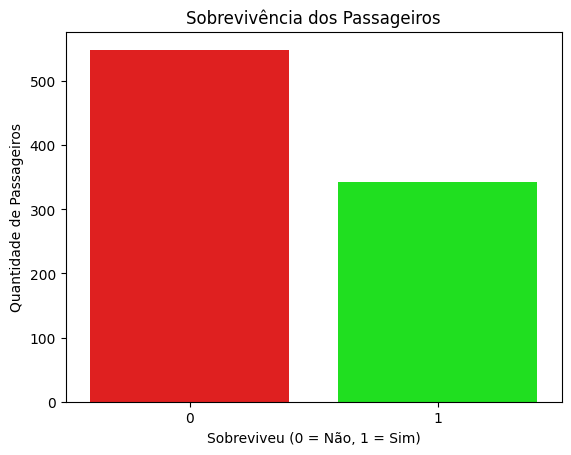

In [ ]:
ax_sobrevivencia = sns.countplot(
    data=df,
    x='Sobreviveu',
    hue='Sobreviveu',
    palette={0: 'red', 1: 'lime'},
    legend=False
)

ax_sobrevivencia.set_title("Sobrevivência dos Passageiros")
ax_sobrevivencia.set_xlabel("Sobreviveu (0 = Não, 1 = Sim)")
ax_sobrevivencia.set_ylabel("Quantidade de Passageiros")

plt.show()

In [ ]:
df['Sexo'].value_counts()

,count
Sexo,
male,577
female,314


In [ ]:
df.groupby('Sexo')['Sobreviveu'].mean()

,Sobreviveu
Sexo,
female,0.742038
male,0.188908


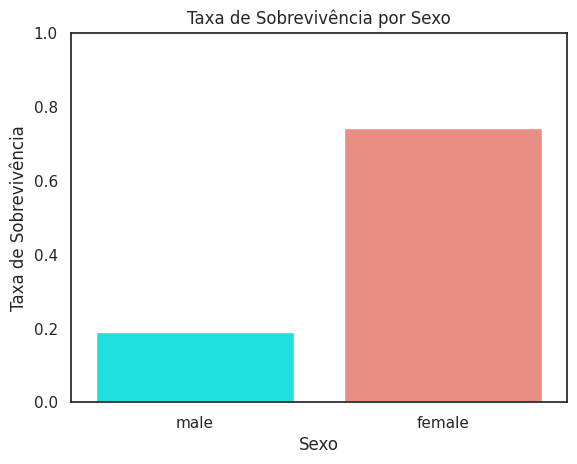

In [ ]:
ax_sexo = sns.barplot(
    data=df,
    x='Sexo',
    y='Sobreviveu',
    estimator='mean',
    hue='Sexo',
    palette={'male':'aqua', 'female':'salmon'},
    errorbar=None
)

ax_sexo.set_title("Taxa de Sobrevivência por Sexo")
ax_sexo.set_ylabel("Taxa de Sobrevivência")
ax_sexo.set_ylim(0, 1)

plt.show()

In [ ]:
df['Classe'].value_counts()

,count
Classe,
3,491
1,216
2,184


In [ ]:
df.groupby('Classe')['Sobreviveu'].sum()

,Sobreviveu
Classe,
1,136
2,87
3,119


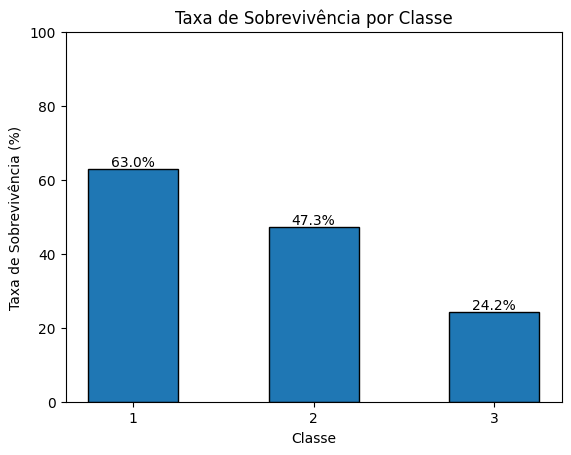

In [ ]:
taxa_classe = df.groupby('Classe')['Sobreviveu'].mean() * 100

plt.bar(
    taxa_classe.index,
    taxa_classe.values,
    edgecolor = 'black',
    width = 0.5
)

plt.title("Taxa de Sobrevivência por Classe")
plt.xlabel("Classe")
plt.xticks([1, 2, 3])
plt.ylabel("Taxa de Sobrevivência (%)")
plt.ylim(0, 100)

# valores em cima das barras
for i, valor in enumerate(taxa_classe.values):
    plt.text(
        taxa_classe.index[i],
        valor,
        f"{valor:.1f}%",
        ha='center',
        va='bottom'
    )

plt.show()

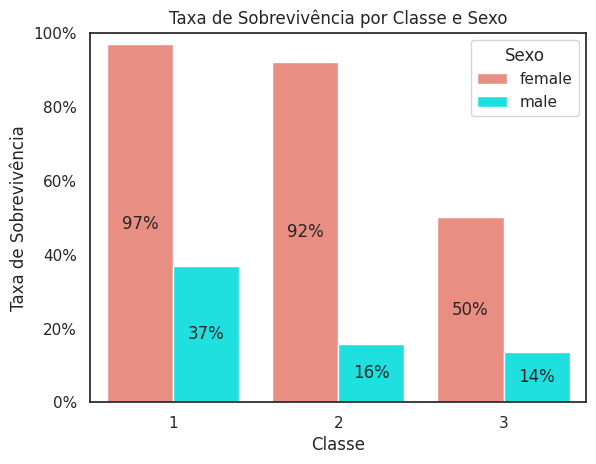

In [ ]:
ax_classe_sexo = sns.barplot(
    data=df,
    x='Classe',
    y='Sobreviveu',
    hue='Sexo',
    palette={'male':'aqua', 'female':'salmon'},
    errorbar=None
)

for container in ax_classe_sexo.containers:
    ax_classe_sexo.bar_label(
        container, fmt='%.0f%%',
        labels=[f'{v*100:.0f}%' for v in container.datavalues],
        label_type='center',
        )

ax_classe_sexo.set_ylim(0, 1)
ax_classe_sexo.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax_classe_sexo.set_title('Taxa de Sobrevivência por Classe e Sexo')
ax_classe_sexo.set_xlabel('Classe')
ax_classe_sexo.set_ylabel('Taxa de Sobrevivência')

plt.show()

In [ ]:
df.query("Classe == 1 and Sexo == 'female' and Sobreviveu == 0")

,Id_Passageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Bilhete,Tarifa,Cabine,Porto_Embarque,Tamanho_Familia
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,PC 17595,28.7125,C49,C,0
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.0,113781,151.5500,C22 C26,S,3
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,113781,151.5500,C22 C26,S,3
